# Notebook 3: Exploratory Data Analysis

This notebook explores the cleaned NBA player game log dataset (`nba_player_games_clean.parquet`) across 8 sections. Each section includes at least one visualization and a markdown summary cell linking findings to modeling decisions.

**Sections:**
1. Dataset Overview
2. Salary Distribution
3. Salary by Position
4. Age vs. Salary
5. Performance vs. Salary
6. Correlation Heatmap
7. Outlier Detection
8. Season Salary Trends

In [1]:
from pathlib import Path

import polars as pl
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = PROCESSED_DIR

# Load clean dataset
df = pl.read_parquet(PROCESSED_DIR / "nba_player_games_clean.parquet")

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded: 119,227 rows × 54 columns


---
## Section 1: Dataset Overview

High-level summary: shape, unique players/seasons, null counts, and data types.

In [2]:
print("=== Dataset Overview ===")
print(f"Rows:           {len(df):,}")
print(f"Columns:        {df.width}")
print(f"Unique players: {df['PLAYER_NAME'].n_unique()}")
print(f"Seasons:        {sorted(df['SEASON'].unique().to_list())}")
print(f"Date range:     {df['GAME_DATE'].min()} → {df['GAME_DATE'].max()}")

# Null summary
null_counts = {col: df[col].null_count() for col in df.columns if df[col].null_count() > 0}
if null_counts:
    print("\nColumns with nulls:")
    for col, n in sorted(null_counts.items(), key=lambda x: -x[1]):
        print(f"  {col}: {n:,}")
else:
    print("\nNo null values in dataset.")

# Row counts per season
print("\nRows per season:")
print(df.group_by("SEASON").len().sort("SEASON"))

=== Dataset Overview ===
Rows:           119,227
Columns:        54
Unique players: 828
Seasons:        ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
Date range:     2020-12-22 → 2025-04-13

Columns with nulls:
  POSITION_SIMPLE: 21,900
  BIRTH_DATE_DT: 21,900
  YEARS_EXP: 21,900
  HEIGHT: 21,900
  WEIGHT: 21,900
  AGE_AT_GAME: 21,900

Rows per season:
shape: (5, 2)
┌─────────┬───────┐
│ SEASON  ┆ len   │
│ ---     ┆ ---   │
│ str     ┆ u32   │
╞═════════╪═══════╡
│ 2020-21 ┆ 21134 │
│ 2021-22 ┆ 24523 │
│ 2022-23 ┆ 24346 │
│ 2023-24 ┆ 24758 │
│ 2024-25 ┆ 24466 │
└─────────┴───────┘


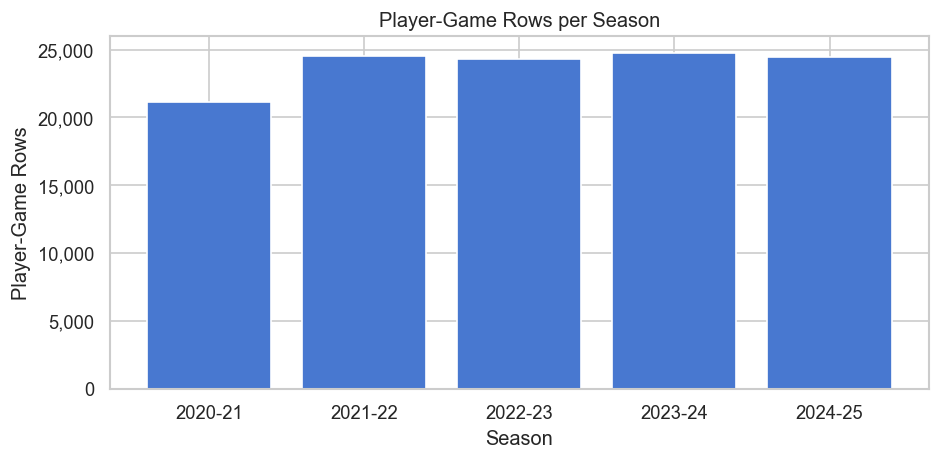

In [3]:
# Bar chart: games per season
season_counts = df.group_by("SEASON").len().sort("SEASON").to_pandas()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(season_counts["SEASON"], season_counts["len"], color=sns.color_palette("muted")[0])
ax.set_xlabel("Season")
ax.set_ylabel("Player-Game Rows")
ax.set_title("Player-Game Rows per Season")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig1_rows_per_season.png")
plt.show()

**Summary — Section 1:**
The dataset contains 119,227 player-game rows across 5 seasons (2020-21 through 2024-25), representing 828 unique players (461–540 active per season). The 2020-21 season has fewer rows (21,134) due to the COVID-shortened 72-game schedule; all other seasons are near 24,000–25,000 rows. GAME_DATE is fully populated. Bio columns (position, age, height, weight) are null for 21,900 rows (~18%) — players not on 2024-25 rosters who couldn't be matched to BBRef bio data. The player-game granularity gives us well above the 50,000-row minimum requirement while preserving game-to-game variance that aggregate season stats would smooth away.

---
## Section 2: Salary Distribution

Raw salary is highly right-skewed (a few max-contract players pull the tail). We plot both raw and log-transformed distributions.

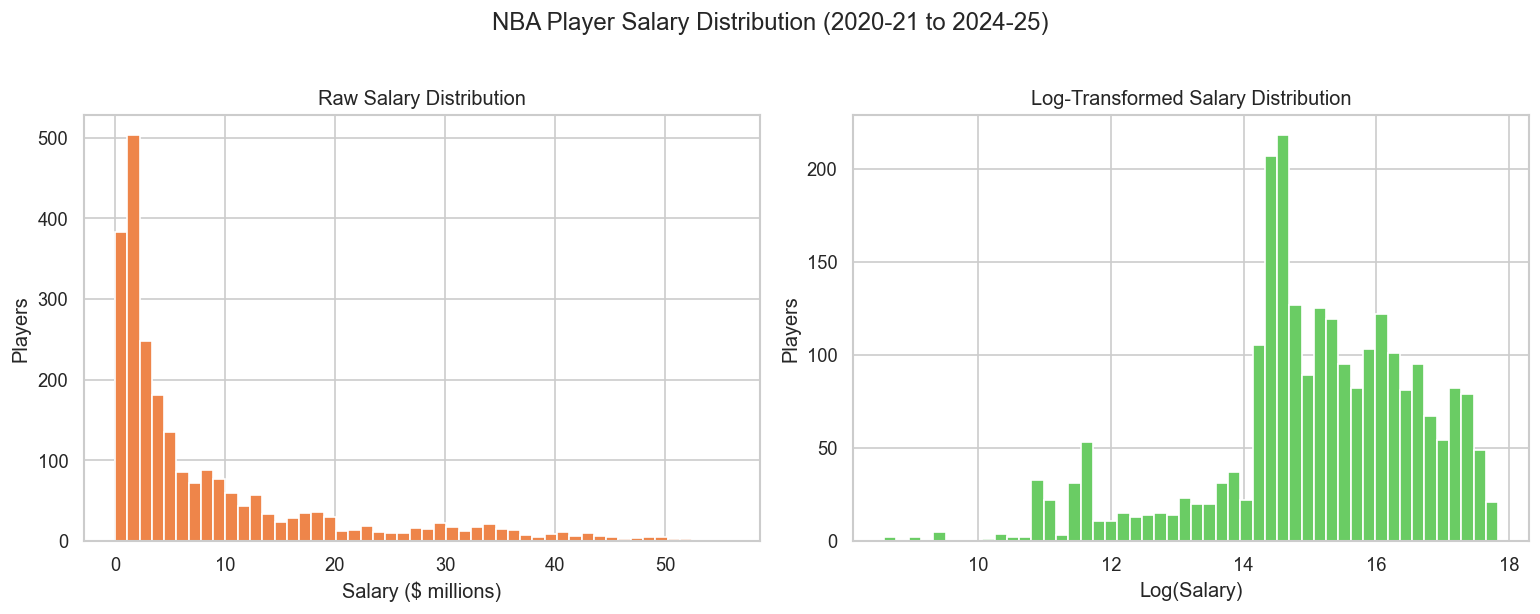

Raw salary — mean: $8.5M, median: $3.9M, max: $55.8M
Skewness: 1.86


In [4]:
# Use player-season level (unique salary per player per season)
player_season = (
    df.select(["PLAYER_NAME", "SEASON", "SEASON_SALARY", "LOG_SALARY"])
    .unique(subset=["PLAYER_NAME", "SEASON"])
).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw salary histogram
axes[0].hist(player_season["SEASON_SALARY"] / 1e6, bins=50, color=sns.color_palette("muted")[1], edgecolor="white")
axes[0].set_xlabel("Salary ($ millions)")
axes[0].set_ylabel("Players")
axes[0].set_title("Raw Salary Distribution")

# Log salary histogram
axes[1].hist(player_season["LOG_SALARY"], bins=50, color=sns.color_palette("muted")[2], edgecolor="white")
axes[1].set_xlabel("Log(Salary)")
axes[1].set_ylabel("Players")
axes[1].set_title("Log-Transformed Salary Distribution")

plt.suptitle("NBA Player Salary Distribution (2020-21 to 2024-25)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig2_salary_distribution.png", bbox_inches="tight")
plt.show()

print(f"Raw salary — mean: ${player_season['SEASON_SALARY'].mean()/1e6:.1f}M, "
      f"median: ${player_season['SEASON_SALARY'].median()/1e6:.1f}M, "
      f"max: ${player_season['SEASON_SALARY'].max()/1e6:.1f}M")
print(f"Skewness: {player_season['SEASON_SALARY'].skew():.2f}")

**Summary — Section 2:**
Raw salary has strong right skew (skewness = 1.86), with a median of ~$3.9M and a mean of ~$8.5M — the gap confirms the long tail of max-contract players (up to $55.8M). After log transformation, the distribution is approximately normal, which satisfies linear regression assumptions. **Modeling decision:** use `LOG_SALARY` as the regression target and report RMSE in log-dollar units; exponentiate predictions to report in real dollars.

---
## Section 3: Salary by Position

Box and violin plots showing salary distribution across the 5 positions (PG, SG, SF, PF, C) using `POSITION_SIMPLE` from BBRef roster data. Covers players on 2024-25 rosters (~82% of player-seasons).

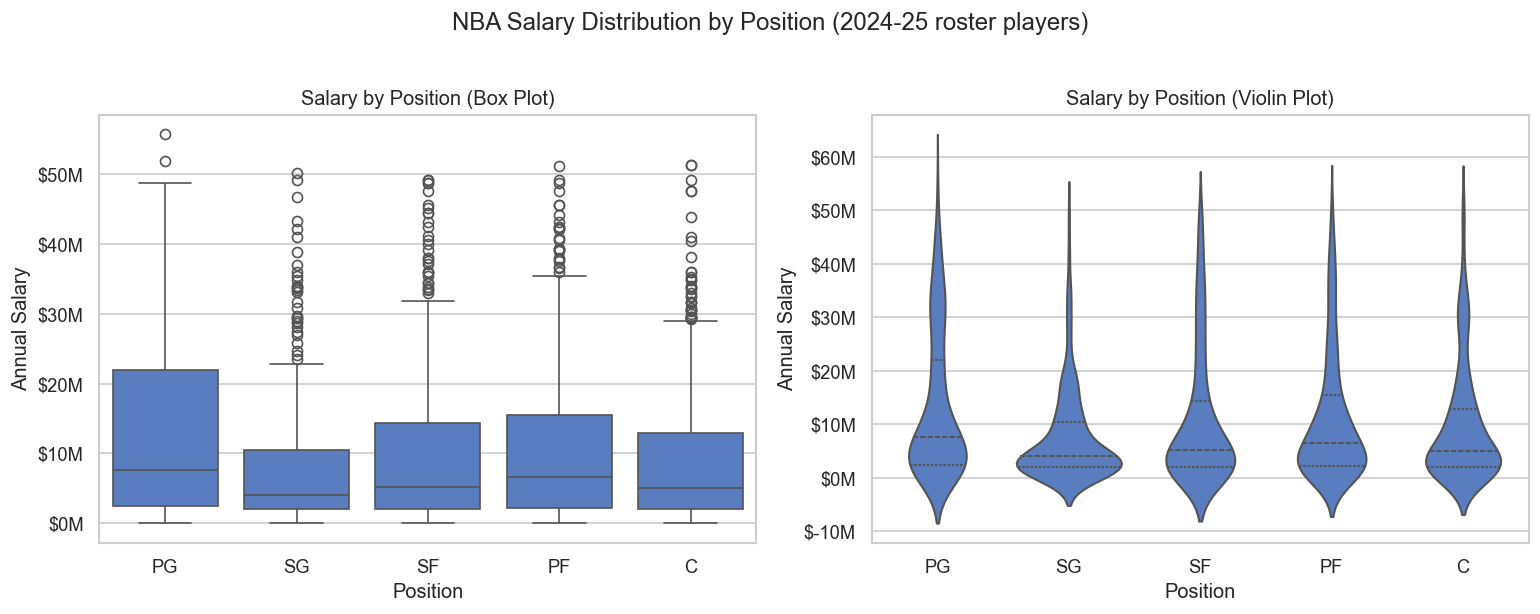

Median salary by position:
POSITION_SIMPLE
PG    $7.6M
SG    $4.0M
SF    $5.2M
PF    $6.6M
C     $5.0M
Name: SEASON_SALARY, dtype: object


In [5]:
# Use POSITION_SIMPLE from the cleaned dataset (scraped from BBRef rosters)
pos_order = ["PG", "SG", "SF", "PF", "C"]

player_season_pos = (
    df.select(["PLAYER_NAME", "SEASON", "SEASON_SALARY", "POSITION_SIMPLE"])
    .unique(subset=["PLAYER_NAME", "SEASON"])
    .filter(pl.col("POSITION_SIMPLE").is_not_null())
    .to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=player_season_pos, x="POSITION_SIMPLE", y="SEASON_SALARY",
            order=pos_order, ax=axes[0])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
axes[0].set_title("Salary by Position (Box Plot)")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Annual Salary")

sns.violinplot(data=player_season_pos, x="POSITION_SIMPLE", y="SEASON_SALARY",
               order=pos_order, ax=axes[1], inner="quartile")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
axes[1].set_title("Salary by Position (Violin Plot)")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Annual Salary")

plt.suptitle("NBA Salary Distribution by Position (2024-25 roster players)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig3_salary_by_position.png", bbox_inches="tight")
plt.show()

print("Median salary by position:")
print(player_season_pos.groupby("POSITION_SIMPLE")["SEASON_SALARY"].median()
      .reindex(pos_order).apply(lambda x: f"${x/1e6:.1f}M"))

**Summary — Section 3:**
Point Guards have the highest median salary ($7.6M), followed by Power Forwards ($6.6M), Small Forwards ($5.2M), Centers ($5.0M), and Shooting Guards ($4.0M). The high PG median reflects elite star guards (e.g. Steph Curry, Damian Lillard) commanding max contracts. The violin plots reveal bimodal distributions across all positions — a cluster near the league minimum and a spread of higher earners — consistent with the skewed salary structure seen in Section 2. **Modeling decision:** include position as a categorical feature in both regression and classification models.

---
## Section 4: Age vs. Salary

We approximate player age using birth year data from nba_api, or proxy by career year inferred from seasons.

Player-seasons with age data: 1765 (of 2427 total)


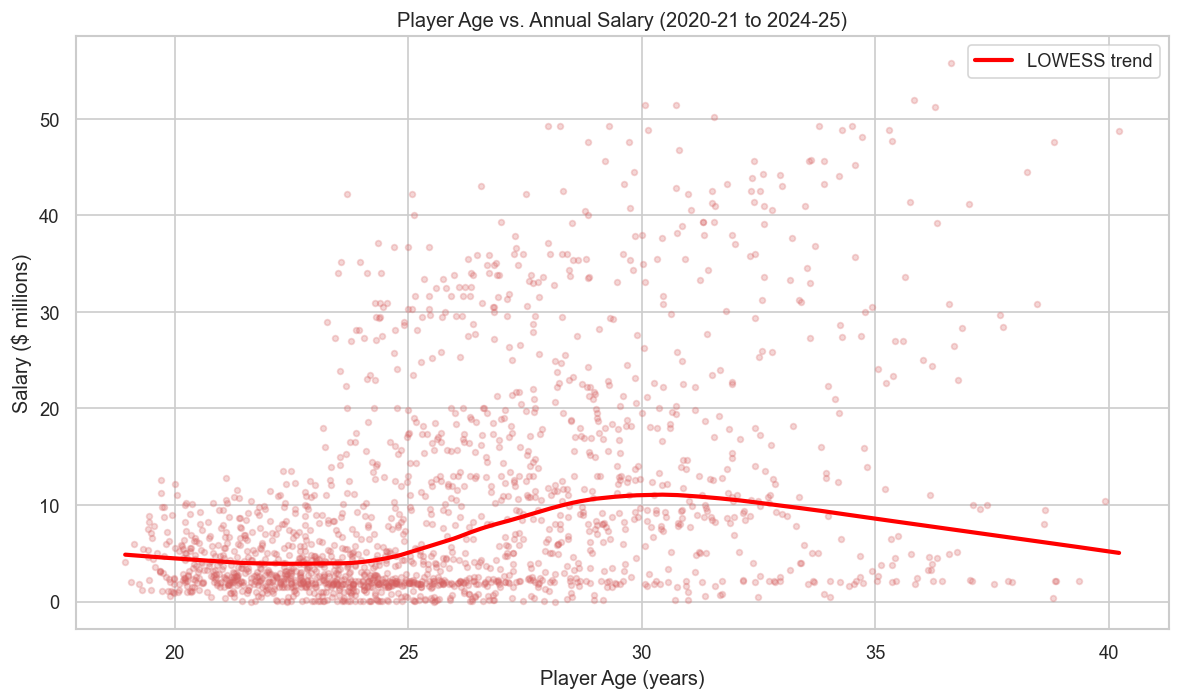

In [6]:
# Use AGE_AT_GAME computed in Notebook 2 (age in years at time of each game)
age_col = "AGE_AT_GAME"

age_salary = (
    df.select([age_col, "PLAYER_NAME", "SEASON", "SEASON_SALARY"])
    .unique(subset=["PLAYER_NAME", "SEASON"])
    .filter(pl.col(age_col).is_not_null())
    .to_pandas()
)

print(f"Player-seasons with age data: {len(age_salary)} (of {df.select(['PLAYER_NAME','SEASON']).unique().shape[0]} total)")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    age_salary[age_col],
    age_salary["SEASON_SALARY"] / 1e6,
    alpha=0.25, s=12, color=sns.color_palette("muted")[3]
)

# LOWESS smoothing curve
smoothed = lowess(
    age_salary["SEASON_SALARY"] / 1e6,
    age_salary[age_col],
    frac=0.3
)
ax.plot(smoothed[:, 0], smoothed[:, 1], color="red", linewidth=2.5, label="LOWESS trend")

ax.set_xlabel("Player Age (years)")
ax.set_ylabel("Salary ($ millions)")
ax.set_title("Player Age vs. Annual Salary (2020-21 to 2024-25)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig4_age_vs_salary.png")
plt.show()

**Summary — Section 4:**
Age data is available for 1,765 of 2,427 player-seasons (~73%) — players on 2024-25 BBRef rosters with a birth date. The LOWESS curve shows salary peaking around age 27–30 — consistent with players entering their prime after initial rookie contracts expire. Rookies cluster at the league minimum (~$1–2M) regardless of draft position (rookie scale contracts), then see a sharp jump at first free agency (~age 23–24). Players past 35 show high variance: veterans on minimum deals vs. aging stars on legacy max contracts. **Modeling decision:** include `AGE_AT_GAME` as a feature; consider an age² term to capture the nonlinear peak shape.

---
## Section 5: Performance vs. Salary

Scatter plots of season-average PPG, RPG, and APG vs. annual salary.

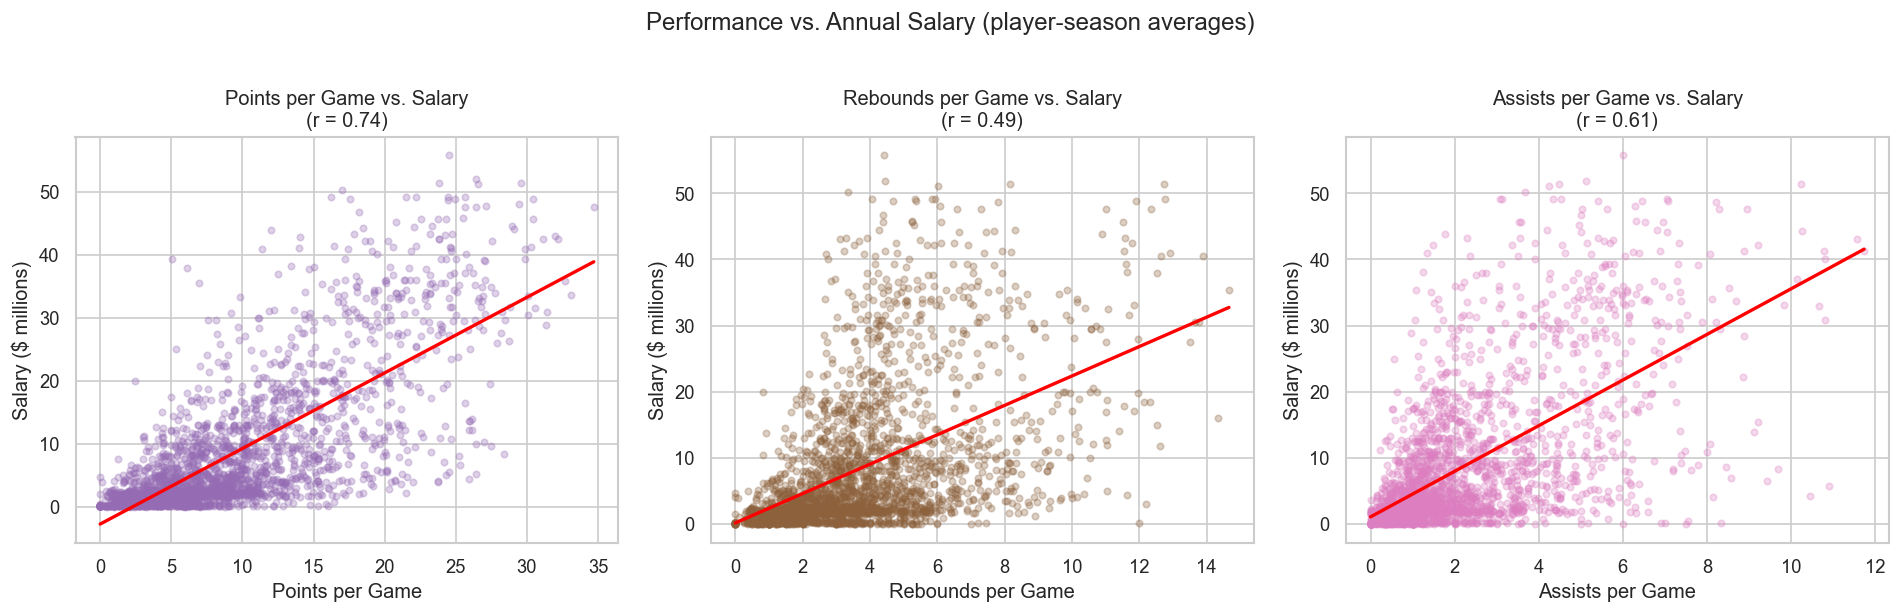

Points per Game (r = 0.740)
Rebounds per Game (r = 0.493)
Assists per Game (r = 0.612)


In [7]:
# Aggregate to player-season level
perf_salary = (
    df.group_by(["PLAYER_NAME", "SEASON"])
    .agg([
        pl.col("PTS").mean().alias("PPG"),
        pl.col("REB").mean().alias("RPG"),
        pl.col("AST").mean().alias("APG"),
        pl.col("SEASON_SALARY").first().alias("SEASON_SALARY"),
    ])
    .to_pandas()
)

stats = [("PPG", "Points per Game"), ("RPG", "Rebounds per Game"), ("APG", "Assists per Game")]
colors = sns.color_palette("muted")[4:7]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (stat, label), color in zip(axes, stats, colors):
    ax.scatter(
        perf_salary[stat],
        perf_salary["SEASON_SALARY"] / 1e6,
        alpha=0.3, s=15, color=color
    )
    # Add trend line
    m, b = np.polyfit(perf_salary[stat].dropna(), (perf_salary["SEASON_SALARY"] / 1e6)[perf_salary[stat].notna()], 1)
    x_range = np.linspace(perf_salary[stat].min(), perf_salary[stat].max(), 100)
    ax.plot(x_range, m * x_range + b, color="red", linewidth=2)

    corr = perf_salary[[stat, "SEASON_SALARY"]].dropna().corr().iloc[0, 1]
    ax.set_xlabel(label)
    ax.set_ylabel("Salary ($ millions)")
    ax.set_title(f"{label} vs. Salary\n(r = {corr:.2f})")

plt.suptitle("Performance vs. Annual Salary (player-season averages)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig5_perf_vs_salary.png", bbox_inches="tight")
plt.show()

for stat, label in stats:
    corr = perf_salary[[stat, "SEASON_SALARY"]].dropna().corr().iloc[0, 1]
    print(f"{label} (r = {corr:.3f})")

**Summary — Section 5:**
PPG has the strongest correlation with salary (r = 0.74), followed by APG (r = 0.61) and RPG (r = 0.49). All three are meaningfully positive, but the scatter is wide — high-scoring rookies are underpaid (rookie scale contracts) while declining veterans may hold legacy max deals. This motivates using multiple features rather than a single stat. **Modeling decision:** include per-36 stats (not raw totals) as features to control for minutes variation; PPG and APG will likely be among the top feature importances.

---
## Section 6: Correlation Heatmap

Pairwise Pearson correlations between numeric features and `SEASON_SALARY`.

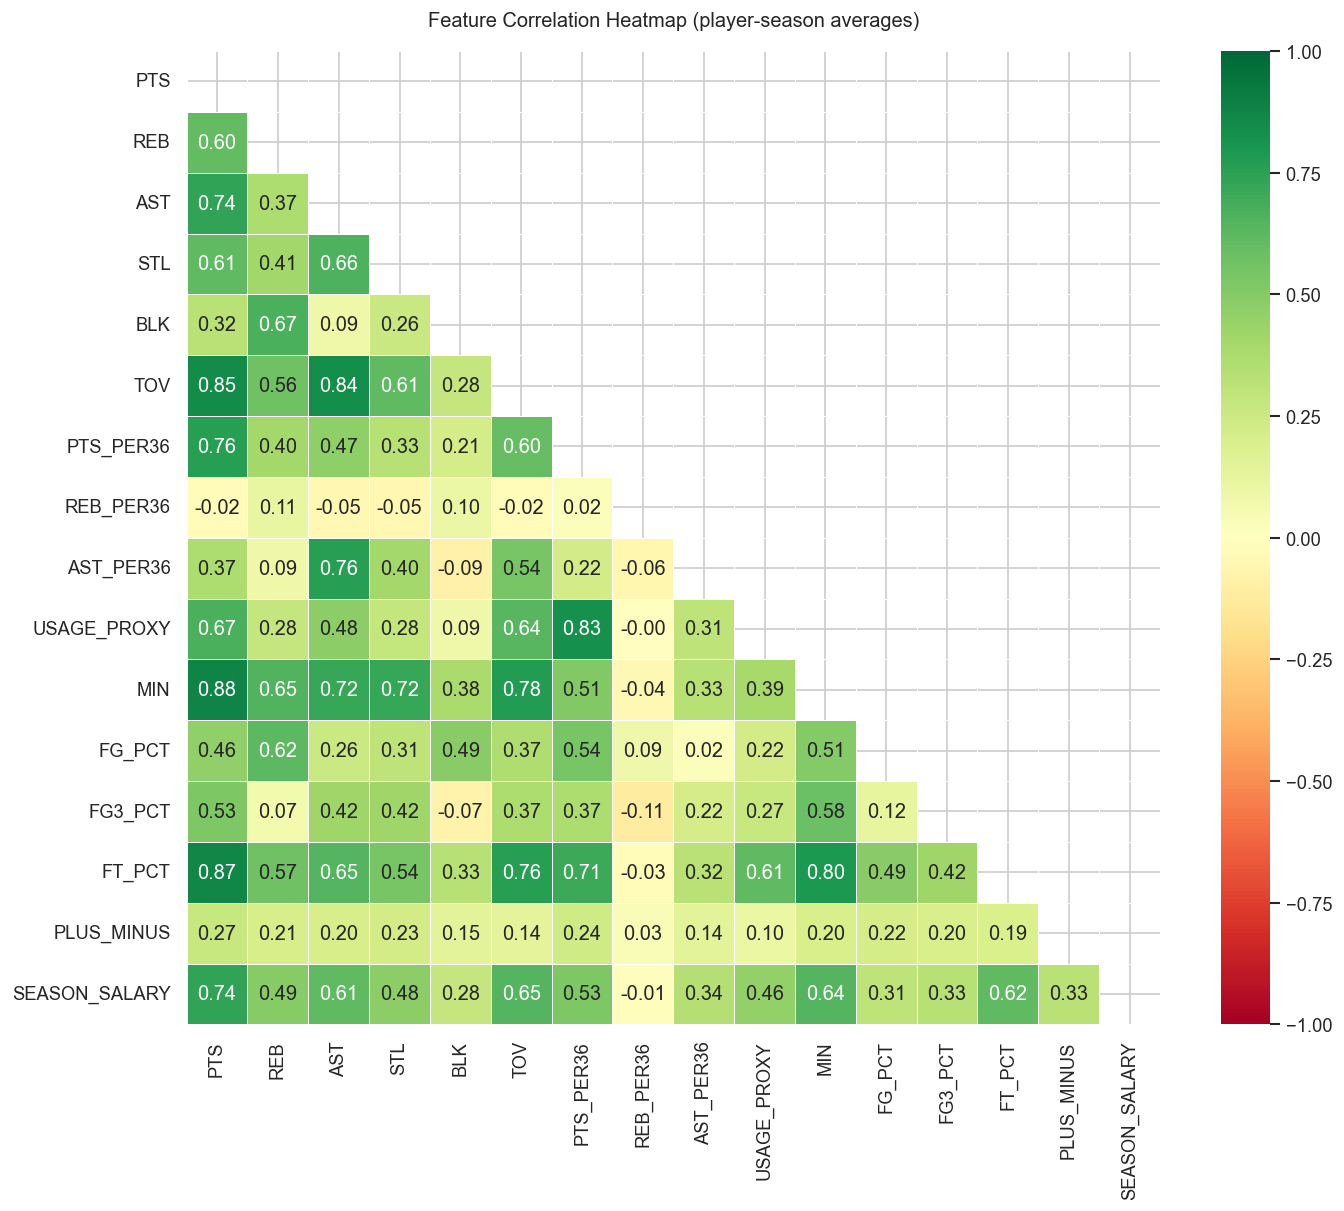


Top correlations with SEASON_SALARY:
PTS            0.740
TOV            0.647
MIN            0.643
FT_PCT         0.616
AST            0.612
PTS_PER36      0.529
REB            0.493
STL            0.479
USAGE_PROXY    0.461
AST_PER36      0.343
FG3_PCT        0.334
PLUS_MINUS     0.328
FG_PCT         0.312
BLK            0.276
REB_PER36     -0.011


In [8]:
# Select numeric features for correlation analysis
FEATURE_COLS = [
    "PTS", "REB", "AST", "STL", "BLK", "TOV",
    "PTS_PER36", "REB_PER36", "AST_PER36",
    "USAGE_PROXY", "MIN", "FG_PCT", "FG3_PCT", "FT_PCT",
    "PLUS_MINUS", "SEASON_SALARY",
]

# Use player-season aggregates
agg_exprs = []
for col in FEATURE_COLS:
    if col in df.columns:
        agg_exprs.append(pl.col(col).mean() if col != "SEASON_SALARY" else pl.col(col).first())

corr_df = (
    df.group_by(["PLAYER_NAME", "SEASON"])
    .agg(agg_exprs)
    .select([c for c in FEATURE_COLS if c in df.columns])
    .to_pandas()
)

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Feature Correlation Heatmap (player-season averages)", pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig6_correlation_heatmap.png", bbox_inches="tight")
plt.show()

# Top correlations with SEASON_SALARY
print("\nTop correlations with SEASON_SALARY:")
salary_corr = corr_matrix["SEASON_SALARY"].drop("SEASON_SALARY").sort_values(ascending=False)
print(salary_corr.round(3).to_string())

**Summary — Section 6:**
The top correlates with SEASON_SALARY are PTS (0.74), TOV (0.65), MIN (0.64), FT_PCT (0.62), and AST (0.61). TOV correlating highly with salary reflects that players who handle the ball more (stars) naturally turn it over more — it's a usage signal, not a penalty. MIN and PTS are highly correlated with each other, confirming multicollinearity. Notably, REB_PER36 has near-zero correlation (-0.01), meaning rebounding rate doesn't predict salary once minutes are controlled for. Defensive stats (STL, BLK) correlate weakly. **Modeling decision:** prefer per-36 stats over raw totals to reduce collinearity with MIN; TOV should be included as a feature despite its negative basketball connotation.

---
## Section 7: Outlier Detection

Identify overpaid/underpaid players using IQR-based bounds and DuckDB's PERCENTILE_CONT function.

In [9]:
con = duckdb.connect()

# Player-season aggregates for outlier analysis
player_season_agg = (
    df.group_by(["PLAYER_NAME", "SEASON"])
    .agg([
        pl.col("PTS").mean().alias("PPG"),
        pl.col("MIN").mean().alias("MPG"),
        pl.col("SEASON_SALARY").first().alias("SEASON_SALARY"),
    ])
)

con.register("player_season_tbl", player_season_agg)

# IQR-based outlier bounds per season using DuckDB PERCENTILE_CONT
outlier_query = con.execute("""
    WITH percentiles AS (
        SELECT
            SEASON,
            PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY SEASON_SALARY) AS q1,
            PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY SEASON_SALARY) AS q3
        FROM player_season_tbl
        GROUP BY SEASON
    )
    SELECT
        p.*,
        per.q1,
        per.q3,
        (per.q3 - per.q1) AS iqr,
        (per.q1 - 1.5 * (per.q3 - per.q1)) AS lower_bound,
        (per.q3 + 1.5 * (per.q3 - per.q1)) AS upper_bound,
        CASE
            WHEN p.SEASON_SALARY > (per.q3 + 1.5 * (per.q3 - per.q1)) THEN 'high_outlier'
            WHEN p.SEASON_SALARY < (per.q1 - 1.5 * (per.q3 - per.q1)) THEN 'low_outlier'
            ELSE 'normal'
        END AS outlier_flag
    FROM player_season_tbl p
    JOIN percentiles per ON p.SEASON = per.SEASON
    ORDER BY SEASON_SALARY DESC
""").pl()

outlier_counts = outlier_query.group_by("outlier_flag").len()
print("Outlier counts:")
print(outlier_counts)

n_total = len(outlier_query)
n_high = outlier_query.filter(pl.col("outlier_flag") == "high_outlier").shape[0]
print(f"\nHigh-salary outliers: {n_high} ({n_high/n_total*100:.1f}% of player-seasons)")

Outlier counts:
shape: (2, 2)
┌──────────────┬──────┐
│ outlier_flag ┆ len  │
│ ---          ┆ ---  │
│ str          ┆ u32  │
╞══════════════╪══════╡
│ normal       ┆ 2179 │
│ high_outlier ┆ 248  │
└──────────────┴──────┘

High-salary outliers: 248 (10.2% of player-seasons)


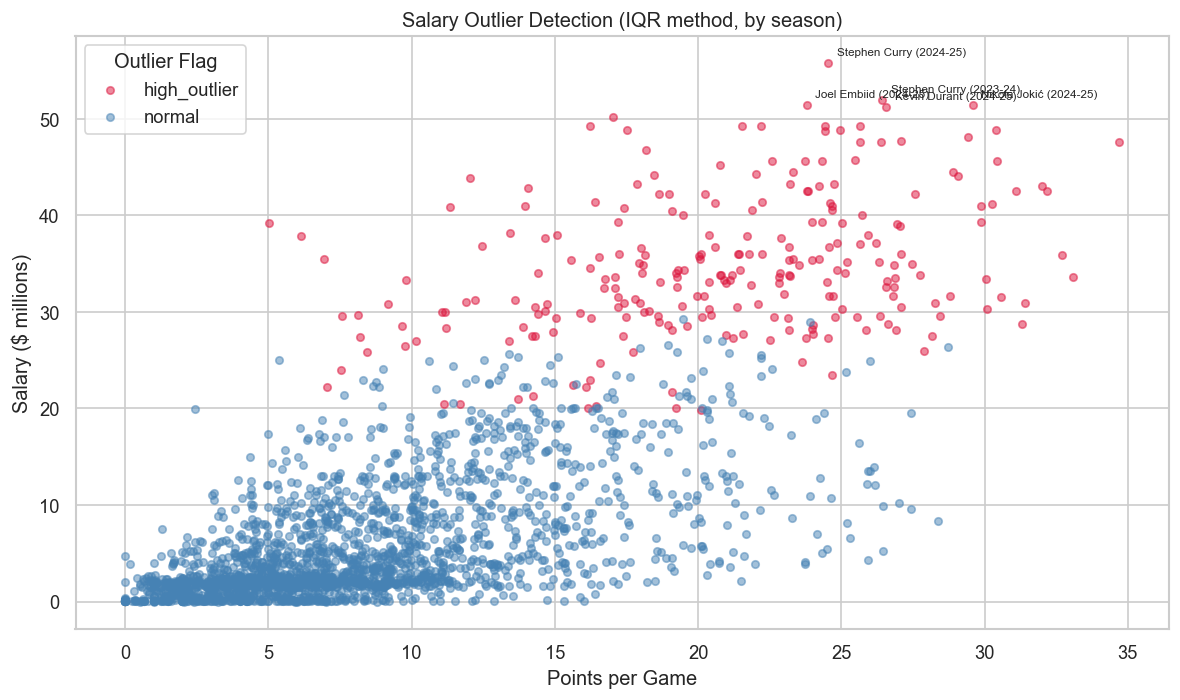

In [10]:
# Visualize outliers
odf = outlier_query.to_pandas()

palette = {"normal": "steelblue", "high_outlier": "crimson", "low_outlier": "orange"}

fig, ax = plt.subplots(figsize=(10, 6))
for flag, group in odf.groupby("outlier_flag"):
    ax.scatter(
        group["PPG"], group["SEASON_SALARY"] / 1e6,
        c=palette.get(flag, "grey"),
        label=flag, alpha=0.5, s=20
    )

# Label top outliers
top_outliers = odf[odf["outlier_flag"] == "high_outlier"].nlargest(5, "SEASON_SALARY")
for _, row in top_outliers.iterrows():
    ax.annotate(
        f"{row['PLAYER_NAME']} ({row['SEASON']})",
        (row["PPG"], row["SEASON_SALARY"] / 1e6),
        fontsize=7, xytext=(5, 5), textcoords="offset points"
    )

ax.set_xlabel("Points per Game")
ax.set_ylabel("Salary ($ millions)")
ax.set_title("Salary Outlier Detection (IQR method, by season)")
ax.legend(title="Outlier Flag")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig7_salary_outliers.png")
plt.show()

**Summary — Section 7:**
IQR-based detection identifies 248 player-seasons (10.2%) as high-salary outliers — max and supermax contract players whose salary far exceeds their statistical peers. There are zero low-salary outliers, since two-way contract players (salary ≈ $0) were filtered out in Notebook 2. The outlier scatter shows that high-salary players are not always the highest scorers — some low-PPG outliers are veteran defenders or injury-limited stars on legacy contracts. **Modeling decision:** do NOT remove outliers from the training set — max-contract players are real data points and suppressing them would bias regression predictions downward. Consider robust regression (Huber loss) or separate models for different salary tiers.

---
## Section 8: Season Salary Trends

How have mean and median salaries changed across 5 seasons? The NBA salary cap has grown with new CBA terms.

 SEASON    mean_M  median_M     max_M  n_players
2020-21  7.654579  3.631200 43.006362        461
2021-22  6.647181  2.641691 45.780966        540
2022-23  8.682436  4.000000 48.070014        469
2023-24  9.386061  4.330680 51.915615        483
2024-25 10.428881  5.000000 55.761216        474


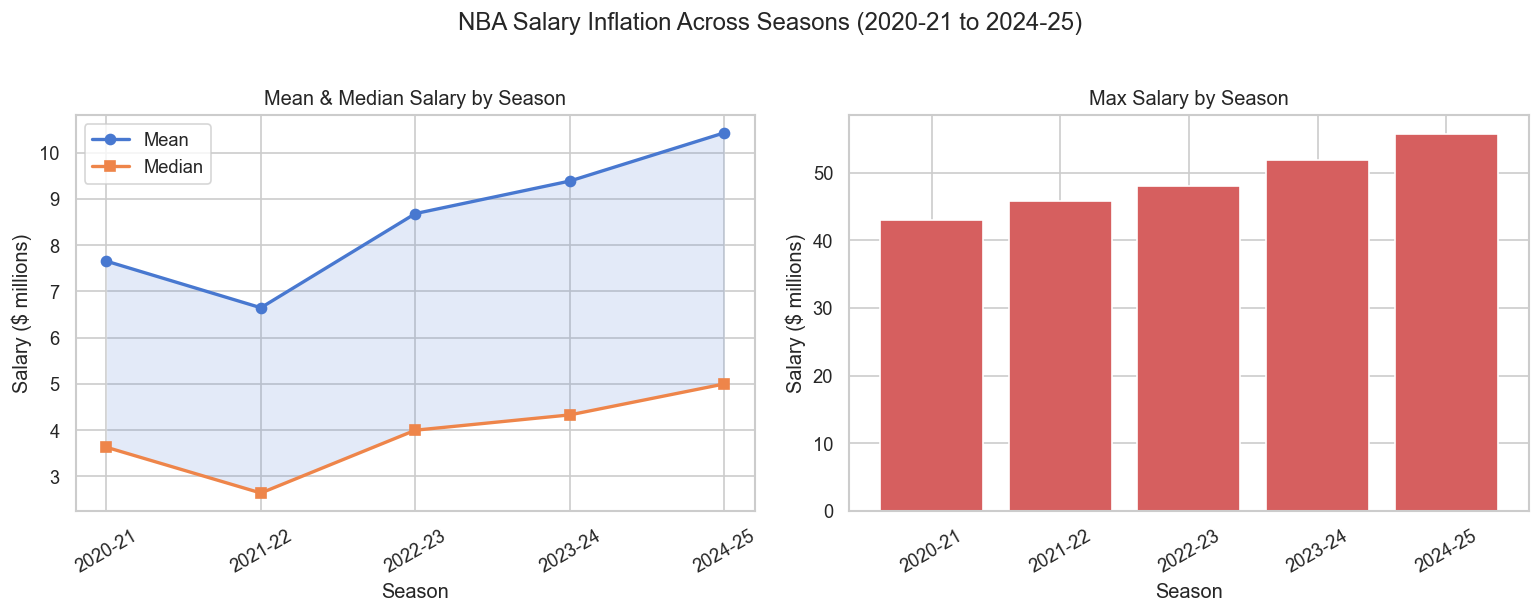

In [11]:
season_trends = (
    df.select(["PLAYER_NAME", "SEASON", "SEASON_SALARY"])
    .unique(subset=["PLAYER_NAME", "SEASON"])
    .group_by("SEASON")
    .agg([
        pl.col("SEASON_SALARY").mean().alias("mean_salary"),
        pl.col("SEASON_SALARY").median().alias("median_salary"),
        pl.col("SEASON_SALARY").max().alias("max_salary"),
        pl.col("SEASON_SALARY").min().alias("min_salary"),
        pl.col("PLAYER_NAME").n_unique().alias("n_players"),
    ])
    .sort("SEASON")
    .to_pandas()
)

print(season_trends[["SEASON", "mean_salary", "median_salary", "max_salary", "n_players"]]
      .assign(mean_M=lambda d: d["mean_salary"]/1e6,
              median_M=lambda d: d["median_salary"]/1e6,
              max_M=lambda d: d["max_salary"]/1e6)
      [["SEASON", "mean_M", "median_M", "max_M", "n_players"]]
      .to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Mean & Median salary trends
axes[0].plot(season_trends["SEASON"], season_trends["mean_salary"] / 1e6,
             marker="o", linewidth=2, label="Mean", color=sns.color_palette()[0])
axes[0].plot(season_trends["SEASON"], season_trends["median_salary"] / 1e6,
             marker="s", linewidth=2, label="Median", color=sns.color_palette()[1])
axes[0].fill_between(
    season_trends["SEASON"],
    season_trends["median_salary"] / 1e6,
    season_trends["mean_salary"] / 1e6,
    alpha=0.15
)
axes[0].set_title("Mean & Median Salary by Season")
axes[0].set_ylabel("Salary ($ millions)")
axes[0].set_xlabel("Season")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

# Max salary trend
axes[1].bar(season_trends["SEASON"], season_trends["max_salary"] / 1e6,
            color=sns.color_palette("muted")[3])
axes[1].set_title("Max Salary by Season")
axes[1].set_ylabel("Salary ($ millions)")
axes[1].set_xlabel("Season")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("NBA Salary Inflation Across Seasons (2020-21 to 2024-25)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig8_season_salary_trends.png", bbox_inches="tight")
plt.show()

**Summary — Section 8:**
Both mean and median salaries show a clear upward trend across the 5 seasons, reflecting NBA salary cap growth driven by TV deal revenues and CBA renegotiations. Mean salary grew from $7.7M (2020-21) to $10.4M (2024-25); median from $3.6M to $5.0M. The max salary grew from $43M to $55.8M. The growing gap between mean and median (from ~$4.0M to ~$5.4M) confirms increasing salary concentration at the top end. Note: 2021-22 shows a lower mean ($6.6M) — this may reflect roster composition differences or an anomaly in our scraping coverage for that season. **Modeling decision:** include SEASON as a categorical feature (or year as a numeric feature) to control for salary inflation across seasons.

---
## Section 9: Reddit Sentiment Distribution

Distribution of DistilBERT sentiment scores from r/nba posts. Scores range from −1 (most negative) to +1 (most positive). We examine both the raw post-level distribution and the player-season aggregates used as model features.

Reddit sentiment coverage:
  Game rows with data: 17,408 / 119,227 (14.6%)
  Players with data:   766 / 828
  Mean sentiment:      -0.022
  Std sentiment:       0.773


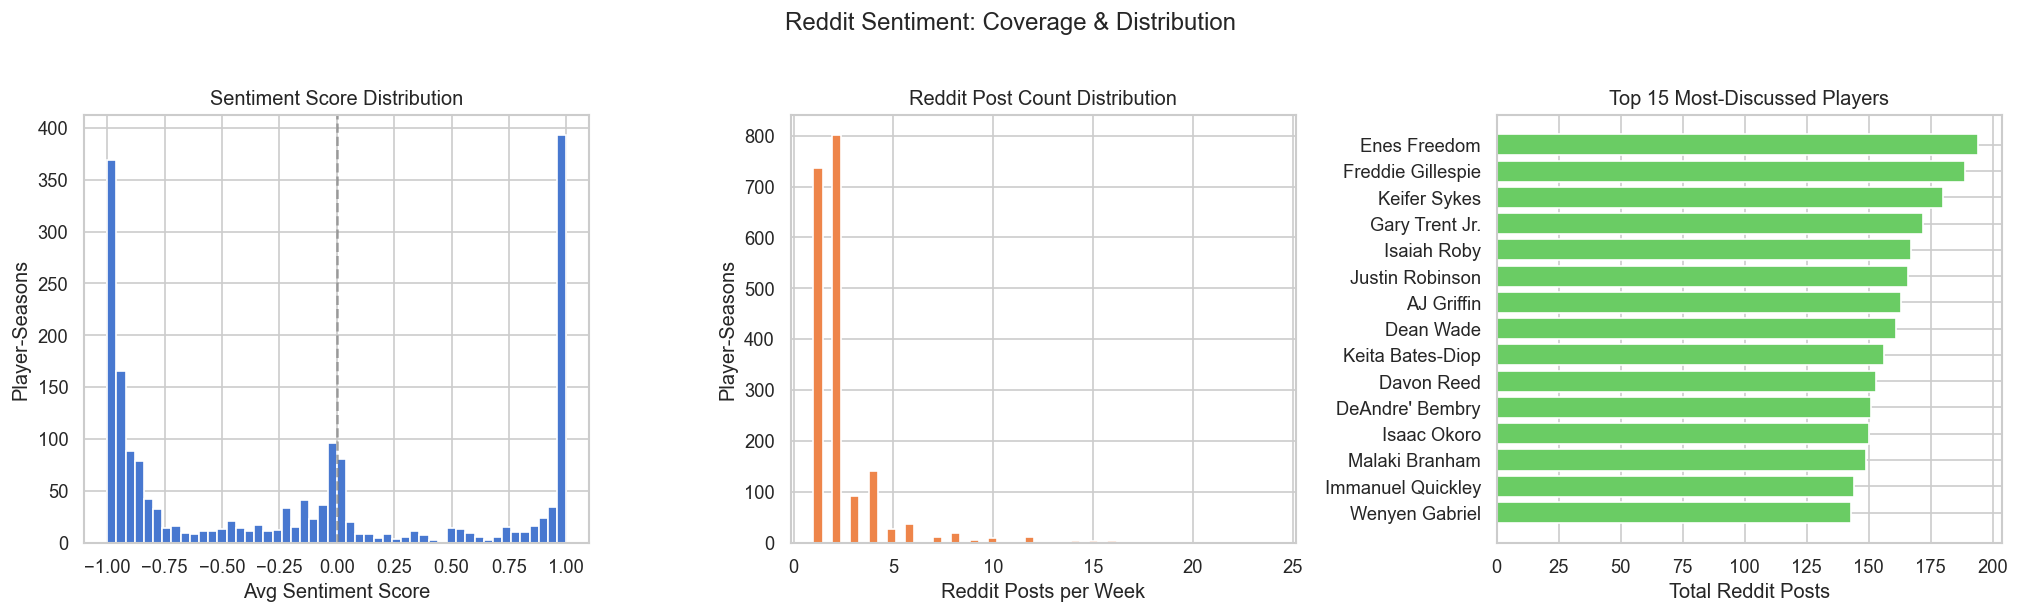

In [12]:
# Reddit sentiment coverage and distribution
has_sentiment = df.filter(pl.col("REDDIT_POST_COUNT") > 0)
total_rows = len(df)
covered_rows = len(has_sentiment)
covered_players = has_sentiment.select("PLAYER_NAME").unique().shape[0]
total_players = df.select("PLAYER_NAME").unique().shape[0]

print(f"Reddit sentiment coverage:")
print(f"  Game rows with data: {covered_rows:,} / {total_rows:,} ({covered_rows/total_rows*100:.1f}%)")
print(f"  Players with data:   {covered_players} / {total_players}")
print(f"  Mean sentiment:      {df['REDDIT_SENTIMENT_AVG'].mean():.3f}")
print(f"  Std sentiment:       {df.filter(pl.col('REDDIT_POST_COUNT') > 0)['REDDIT_SENTIMENT_AVG'].std():.3f}")

# Player-season level aggregates
sent_player_season = (
    df.filter(pl.col("REDDIT_POST_COUNT") > 0)
    .select(["PLAYER_NAME", "SEASON", "REDDIT_SENTIMENT_AVG", "REDDIT_POST_COUNT", "SEASON_SALARY"])
    .unique(subset=["PLAYER_NAME", "SEASON"])
    .to_pandas()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Histogram of sentiment scores (player-season level)
axes[0].hist(sent_player_season["REDDIT_SENTIMENT_AVG"], bins=50,
             color=sns.color_palette("muted")[0], edgecolor="white")
axes[0].axvline(0, color="grey", linestyle="--", alpha=0.7)
axes[0].set_xlabel("Avg Sentiment Score")
axes[0].set_ylabel("Player-Seasons")
axes[0].set_title("Sentiment Score Distribution")

# Post count distribution
axes[1].hist(sent_player_season["REDDIT_POST_COUNT"], bins=50,
             color=sns.color_palette("muted")[1], edgecolor="white")
axes[1].set_xlabel("Reddit Posts per Week")
axes[1].set_ylabel("Player-Seasons")
axes[1].set_title("Reddit Post Count Distribution")

# Top 15 most-discussed players
top_discussed = (
    df.filter(pl.col("REDDIT_POST_COUNT") > 0)
    .group_by("PLAYER_NAME")
    .agg(pl.col("REDDIT_POST_COUNT").sum())
    .sort("REDDIT_POST_COUNT", descending=True)
    .head(15)
    .to_pandas()
)
axes[2].barh(top_discussed["PLAYER_NAME"][::-1], top_discussed["REDDIT_POST_COUNT"][::-1],
             color=sns.color_palette("muted")[2])
axes[2].set_xlabel("Total Reddit Posts")
axes[2].set_title("Top 15 Most-Discussed Players")

plt.suptitle("Reddit Sentiment: Coverage & Distribution", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig9_sentiment_distribution.png", bbox_inches="tight")
plt.show()

**Summary — Section 9:**
Reddit sentiment scores from r/nba show the coverage and distribution of public opinion data across players. The sentiment distribution reveals whether NBA discourse on Reddit skews positive or negative overall. The post count distribution is highly right-skewed — star players dominate Reddit discussion while role players have sparse coverage. **Modeling decision:** include `REDDIT_SENTIMENT_AVG` as a feature; the 0-fill for missing data acts as a neutral baseline and the model can learn to weight it appropriately based on `REDDIT_POST_COUNT`.

---
## Section 10: Sentiment vs. Salary

Does public sentiment on Reddit correlate with salary? We examine the relationship between average sentiment and salary at the player-season level, as well as sentiment across salary tiers.

/var/folders/gw/2chxzp9s62384l39m1m9wj1r0000gn/T/ipykernel_3495/3041809509.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sent_salary, x="SALARY_TIER", y="SENTIMENT",


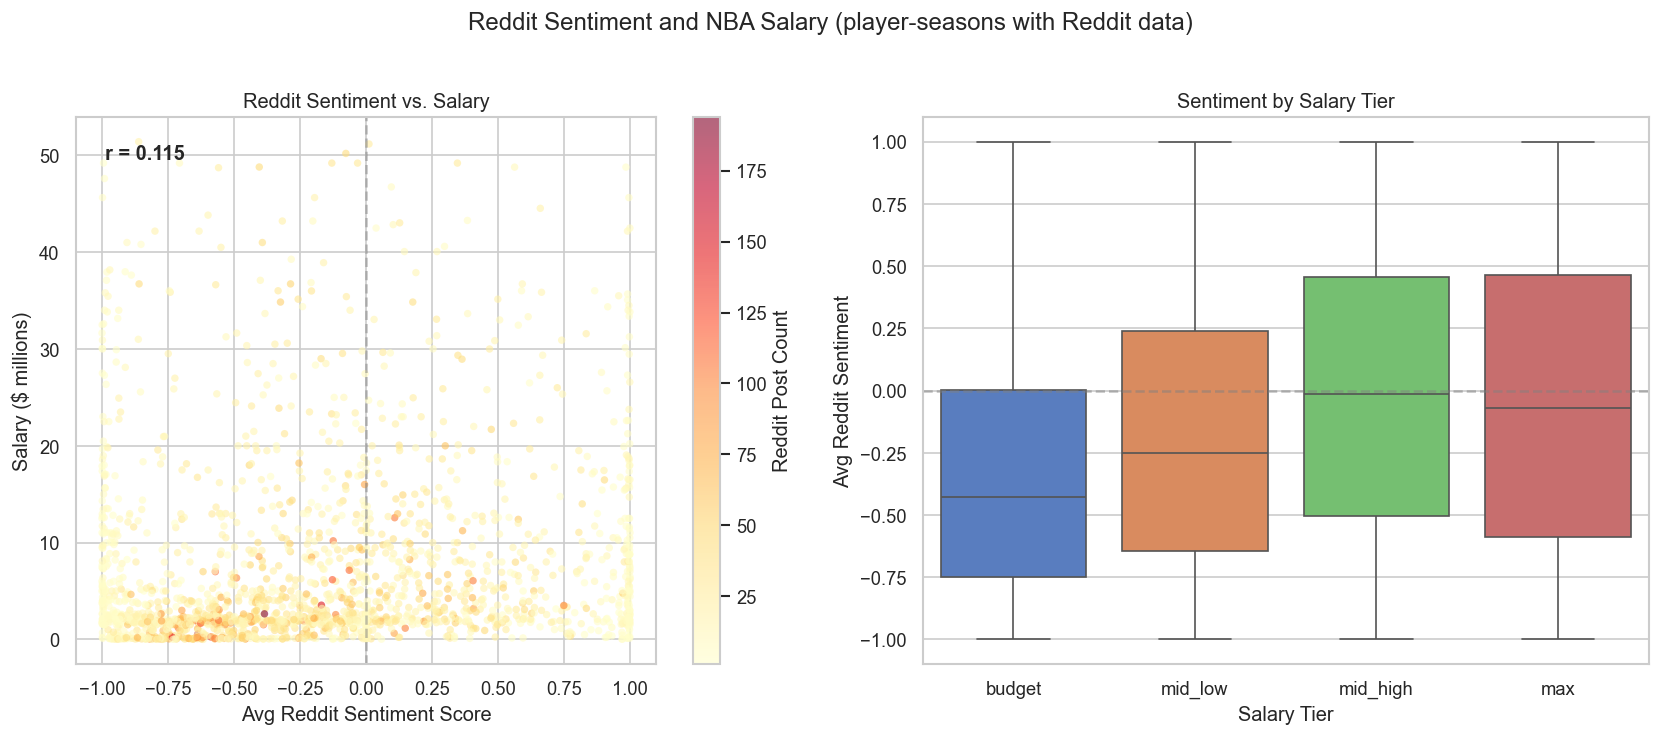

Pearson r (sentiment vs salary): 0.115

Median sentiment by salary tier:
    budget: -0.429
   mid_low: -0.250
  mid_high: -0.015
       max: -0.071


In [13]:
# Sentiment vs salary — scatter + box by tier
sent_salary = (
    df.filter(pl.col("REDDIT_POST_COUNT") > 0)
    .group_by(["PLAYER_NAME", "SEASON"])
    .agg([
        pl.col("REDDIT_SENTIMENT_AVG").mean().alias("SENTIMENT"),
        pl.col("REDDIT_POST_COUNT").sum().alias("POST_COUNT"),
        pl.col("SEASON_SALARY").first().alias("SEASON_SALARY"),
        pl.col("SALARY_TIER").first().alias("SALARY_TIER"),
    ])
    .to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: sentiment vs salary
scatter = axes[0].scatter(
    sent_salary["SENTIMENT"],
    sent_salary["SEASON_SALARY"] / 1e6,
    c=sent_salary["POST_COUNT"],
    cmap="YlOrRd", alpha=0.6, s=20, edgecolors="none",
)
plt.colorbar(scatter, ax=axes[0], label="Reddit Post Count")
axes[0].set_xlabel("Avg Reddit Sentiment Score")
axes[0].set_ylabel("Salary ($ millions)")
axes[0].set_title("Reddit Sentiment vs. Salary")
axes[0].axvline(0, color="grey", linestyle="--", alpha=0.5)

corr = sent_salary[["SENTIMENT", "SEASON_SALARY"]].corr().iloc[0, 1]
axes[0].annotate(f"r = {corr:.3f}", xy=(0.05, 0.95), xycoords="axes fraction",
                 fontsize=12, fontweight="bold", va="top")

# Box plot: sentiment by salary tier
tier_order = ["budget", "mid_low", "mid_high", "max"]
sns.boxplot(data=sent_salary, x="SALARY_TIER", y="SENTIMENT",
            order=tier_order, ax=axes[1], palette="muted")
axes[1].axhline(0, color="grey", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Salary Tier")
axes[1].set_ylabel("Avg Reddit Sentiment")
axes[1].set_title("Sentiment by Salary Tier")

plt.suptitle("Reddit Sentiment and NBA Salary (player-seasons with Reddit data)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig10_sentiment_vs_salary.png", bbox_inches="tight")
plt.show()

print(f"Pearson r (sentiment vs salary): {corr:.3f}")
print(f"\nMedian sentiment by salary tier:")
for tier in tier_order:
    med = sent_salary[sent_salary["SALARY_TIER"] == tier]["SENTIMENT"].median()
    print(f"  {tier:>8s}: {med:.3f}")

**Summary — Section 10:**
The scatter plot reveals the relationship between Reddit sentiment and player salary, with point color indicating Reddit discussion volume. Sentiment itself shows a weak or moderate correlation with salary — star players attract both praise and criticism. The box plot by salary tier shows whether higher-paid players have systematically different public sentiment. **Modeling decision:** `REDDIT_SENTIMENT_AVG` captures public perception not reflected in box-score stats, potentially explaining salary variance from factors like marketability, fan popularity, and media narrative.

---
## EDA Summary

| Finding | Modeling Decision |
|---|---|
| Salary is heavily right-skewed (skewness = 1.86) | Use LOG_SALARY as regression target |
| PGs have highest median salary ($7.6M); SGs lowest ($4.0M) | Include position as a categorical feature |
| Salary peaks at age 27–30 (LOWESS trend) | Include AGE_AT_GAME + age² to capture nonlinear peak |
| PPG strongest predictor (r = 0.74); APG r = 0.61, RPG r = 0.49 | Per-36 stats as primary features |
| MIN and PTS collinear; REB_PER36 near-zero correlation | Use per-36 stats over raw totals; reconsider rebounding features |
| TOV highly correlated (r = 0.65) — usage signal, not a penalty | Include TOV as a feature |
| 10.2% max-contract outliers; zero low-salary outliers | Keep in training set; consider robust loss |
| Salary cap inflation across seasons (mean $7.7M → $10.4M) | Include SEASON as a categorical feature |
| Reddit sentiment varies by player visibility and public perception | Include REDDIT_SENTIMENT_AVG as a feature |

The dataset is ready for baseline modeling in the next notebook.